In [ ]:
!pip install facenet-pytorch &> /dev/null

In [ ]:
import torch
from facenet_pytorch import MTCNN
import matplotlib.pyplot as plt
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

#downloaded = drive.CreateFile({'id': '1nWbItUzADjC3OtN3ijph6S5PIMTYfT2H'})   # replace the id with id of file you want to access
downloaded = drive.CreateFile({'id': '1q_TZucPe1mPfkihARV1vC82TTcmR_NTz'})
downloaded.GetContentFile('esercitazione_Viola-Jones.zip')        # replace the file name with your file
!unzip esercitazione_Viola-Jones
print('Done! Press the Refresh button if files are not visible.')

ModuleNotFoundError: No module named 'mtcnn'

In [ ]:
#Read image from your local file system
original_image = cv2.imread('/content/esercitazione_Viola-Jones/Solvay_conference_1927_(color).jpg')

# Convert color image to grayscale for Viola-Jones
rgb_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

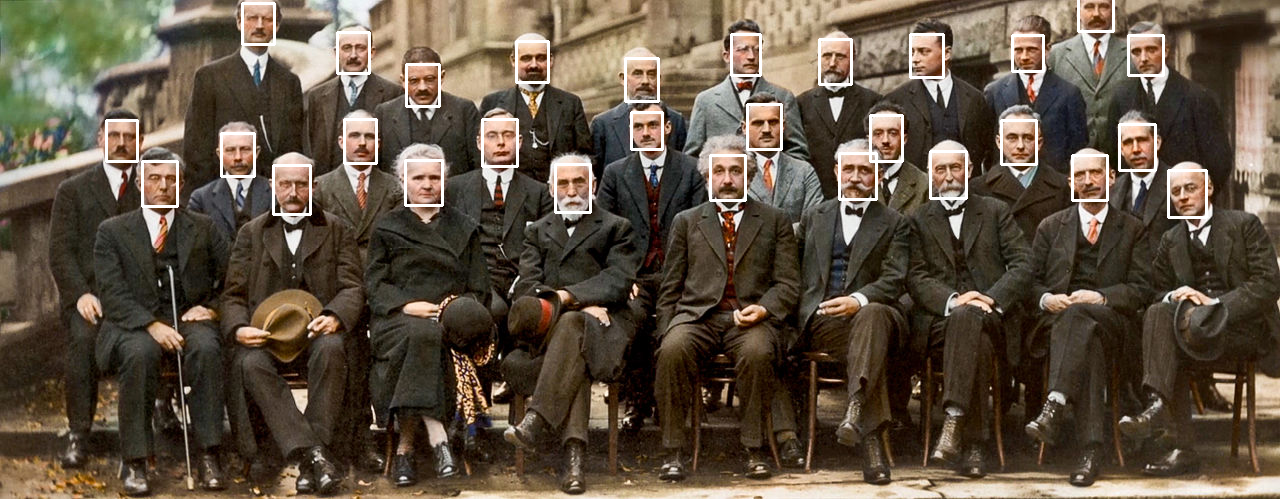

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mtcnn = MTCNN(device=device)

boxes, probs = mtcnn.detect(rgb_image)
if boxes is not None:
    for box, prob in zip(boxes, probs):
      if prob > 0.9: #score of face
        x1, y1, x2, y2 = [int(b) for b in box] # is the same (int(box[0]), int(box[1])....)
        cv2.rectangle(original_image, (x1, y1), (x2, y2), (255, 255, 255), 2)
cv2_imshow(original_image)
